# 🏦 AI Investment Research Analyst
## Single Agent vs Multi-Agent: A Hands-On Comparison

---

### 📋 Problem Statement

An investor wants a **comprehensive investment analysis** on three companies — **Tesla, Apple, and NVIDIA**. They need:

1. Each company's business overview researched
2. Financial metrics compared side-by-side
3. Risks identified for each
4. A final professional investment memo with a buy/hold/sell recommendation

**Why is this hard for a single agent?** Doing all of this in one shot means the LLM must research, analyze, compare, assess risk, AND write — all within one context window. It loses track, produces shallow results, and can't self-review.

**Our approach:**
- ❌ First, we attempt this with a **Single Agent** and observe the failures
- ✅ Then, we rebuild with a **Multi-Agent System** and compare the quality

---

### 🧠 Concepts Covered in This Notebook

| Concept | Section |
|---|---|
| What is an Agent? | Section 1 |
| Single Agent Architecture | Section 2 |
| Single Agent Limitations | Section 2 (Results) |
| Why Multi-Agent Systems? | Section 3 |
| Multi-Agent Orchestration | Section 4 |
| Sequential + Parallel Patterns | Section 4 |
| Handoffs & Communication | Section 4 |
| State Management | Section 4 |
| LangGraph Framework | Section 4 |
| Results Comparison | Section 5 |

---
## 🔧 Section 0: Environment Setup

We install and import all required libraries. Our tech stack:
- **LangChain** — LLM abstraction and tool integration
- **LangGraph** — Graph-based multi-agent orchestration
- **OpenAI GPT-4o-mini** — Our LLM backbone
- **Tavily** — Real-time web search for research
- **Pydantic** — Structured state management

In [35]:
# ============================================================
# Install required packages
# ============================================================
# langchain-openai    -> OpenAI LLM integration
# langchain-community -> Community tools (Tavily search etc.)
# langgraph           -> Graph-based multi-agent orchestration
# tavily-python        -> Real-time web search API
# pydantic            -> Data validation & structured state
# ============================================================

'!pip install -q langchain langchain-openai langchain-community langgraph tavily-python pydantic'


'!pip install -q langchain langchain-openai langchain-community langgraph tavily-python pydantic'

In [36]:
%pip install -U langchain-tavily


  Using cached websockets-15.0.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.8 kB)
Using cached websockets-15.0.1-cp313-cp313-macosx_11_0_arm64.whl (173 kB)
  Attempting uninstall: websockets
    Found existing installation: websockets 16.0
    Uninstalling websockets-16.0:
      Successfully uninstalled websockets-16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 3.38.0 requires numpy~=1.0, but you have numpy 2.5.0 which is incompatible.
gradio 3.38.0 requires websockets<12.0,>=10.0, but you have websockets 15.0.1 which is incompatible.
gradio-client 0.2.10 requires websockets<12.0,>=10.0, but you have websockets 15.0.1 which is incompatible.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have gradio-client 0.2.10 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [37]:
import os
from dotenv import load_dotenv
dotenv_dir='./../../chat_bot/prod_small/' #Replace with your path
env_path=os.path.join(dotenv_dir,'.env')
# Load environment variables from .env file
load_dotenv(env_path)
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')
OPENROUTER_API_KEY = os.getenv('OPEN_ROUTER_KEY')

print("OPENAI_API_KEY:", OPENAI_API_KEY[0:10] )
print("TAVILY_API_KEY:", TAVILY_API_KEY)
print(f"current directory: {env_path}, {os.getcwd()}")


OPENAI_API_KEY: sk-proj-aH
TAVILY_API_KEY: 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
current directory: ./../../chat_bot/prod_small/.env, /Users/uchegodfrey/Downloads/Ik_assignments/transformer/ai_investment


In [38]:
# ============================================================
# API Key Configuration
# ============================================================
# You need two API keys:
# 1. OPENAI_API_KEY   -> For GPT-4o-mini LLM calls
# 2. TAVILY_API_KEY   -> For real-time web search
#
# Get your Tavily key free at: https://tavily.com
# ============================================================
import os
from getpass import getpass

# Set API keys (will prompt you to enter securely)
os.environ["OPENAI_API_KEY"] = str(OPENAI_API_KEY)
os.environ["TAVILY_API_KEY"] = str(TAVILY_API_KEY)
os.environ["OPENROUTER_API_KEY"] = str(OPENROUTER_API_KEY)


In [40]:

# ============================================================
# Import all required libraries
# ============================================================

import json
import time
from typing import Annotated, TypedDict, Literal, List, Optional
from pydantic import BaseModel, Field

# LangChain core
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate

# Tavily search tool for real-time web research
# from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_tavily import TavilySearch

# LangGraph for multi-agent orchestration
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages

print("✅ All imports successful!")


✅ All imports successful!


In [43]:
# ============================================================
# Initialize our LLM and Search Tool
# ============================================================
# We use GPT-4o-mini as our LLM — it's fast, cheap, and capable.
# Tavily gives us real-time web search results.
# ============================================================

# LLM — using GPT-4o-mini for cost efficiency
# temperature=0 for deterministic, factual outputs
#llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

#llm = ChatOpenAI(api_key=os.environ["OPENAI_API_KEY"], model = 'gpt-5.4-nano')

llm = ChatOpenAI(
    openai_api_base="https://openrouter.ai/api/v1",
    openai_api_key=os.environ["OPENROUTER_API_KEY"],
    model="openrouter/free", # Automatically dynamically routes to an open free model
    default_headers={
        "HTTP-Referer": "https://localhost:3000", # Optional, for OpenRouter analytics
        "X-Title": "My LangChain App",            # Optional, for OpenRouter rankings
    },
    temperature=0
)


# Web search tool — returns top 5 results per query
# search_tool = TavilySearchResults(max_results=5)
search_tool = TavilySearch(max_results=5,api_key=str(os.environ["TAVILY_API_KEY"]))
#llm_with_tools = llm.bind_tools([search_tool])
# The companies we'll analyze
COMPANIES = ["Tesla", "Apple", "NVIDIA"]

print("✅ LLM and Search Tool initialized!")
print(f"📊 Companies to analyze: {', '.join(COMPANIES)}")


✅ LLM and Search Tool initialized!
📊 Companies to analyze: Tesla, Apple, NVIDIA


---
## 📖 Section 1: What is an Agent?

Before we start building, let's understand what an **AI Agent** actually is.

### Definition

> **An AI Agent is a software program powered by an LLM that can autonomously understand tasks, plan actions, use tools, and adapt its behavior based on results.**

### Core Components of an Agent

An agent has **4 core components:**

1. **Brain (LLM)** — The reasoning engine. Understands natural language, plans steps, makes decisions.
2. **Planning** — Breaks a complex task into a sequence of smaller steps.
3. **Memory** — Keeps track of past actions and results to inform future decisions.
4. **Tools** — External capabilities the agent can call (APIs, databases, search engines, calculators).

### How an Agent Works

```
User Request → Agent receives task
                  ↓
              Agent PLANS steps
                  ↓
              Agent DECIDES which tool to use
                  ↓
              Agent EXECUTES the tool
                  ↓
              Agent OBSERVES the result
                  ↓
              Agent ADAPTS (repeat or respond)
                  ↓
              Final Response → User
```

This is the **ReAct pattern** — Reason + Act in a loop until the task is complete.

---
## ❌ Section 2: Single Agent Approach

### What is a Single Agent Architecture?

> In a **Single Agent Architecture**, one LLM handles the entire task end-to-end — understanding, planning, researching, analyzing, and generating output — all within a single context window.

### What we expect to go wrong:

- **Context overload** — Researching 3 companies + analysis + risk + report in one prompt is too much for one context window
- **Shallow analysis** — The agent spreads itself thin across all tasks
- **No self-review** — The agent can't critically evaluate its own work
- **Mixing up data** — Facts from one company may bleed into another's analysis

Let's see this in action. 👇

In [44]:
# ============================================================
# SINGLE AGENT: One LLM does EVERYTHING
# ============================================================
# We give one agent the full task:
#   - Research all 3 companies
#   - Analyze financials
#   - Assess risks
#   - Write investment memo
#
# This mimics what happens when you dump a complex task into
# one ChatGPT prompt and hope for the best.
# ============================================================

def run_single_agent(companies: list) -> dict:
    """Attempt the full investment analysis with a single agent."""

    print("="*60)
    print("🤖 SINGLE AGENT: Starting full analysis...")
    print("="*60)

    start_time = time.time()

    # --------------------------------------------------------
    # Step 1: Research all companies (single agent does it all)
    # --------------------------------------------------------
    print("\n📡 Step 1: Researching all companies at once...")

    # Single search query trying to cover everything
    all_research = ""
    for company in companies:
        results = search_tool.invoke(f"{company} financials revenue 2025 2026 AI strategy")['results']
        all_research += f"\n--- {company} Research ---\n"
        for r in results:
            all_research += f"- {r['content'][:300]}\n"

    print(f"   Collected {len(all_research)} chars of research")

    # --------------------------------------------------------
    # Step 2: Single mega-prompt to do EVERYTHING
    # --------------------------------------------------------
    print("\n📝 Step 2: Generating complete analysis in one shot...")

    # This is the single-agent approach: one massive prompt
    mega_prompt = f"""You are an investment analyst. Based on the research below, produce a
                    COMPLETE investment analysis report with ALL of the following:

                    1. COMPANY OVERVIEWS - Business overview for each company
                    2. FINANCIAL COMPARISON - Side-by-side comparison of revenue, growth, margins
                    3. RISK ASSESSMENT - Key risks for each company
                    4. INVESTMENT MEMO - Professional memo with buy/hold/sell recommendation for each

                    Companies: {', '.join(companies)}

                    Research Data:
                    {all_research[:8000]}

                    Produce the FULL report now. Be thorough and specific with numbers."""

    response = llm.invoke([HumanMessage(content=mega_prompt)])

    elapsed = time.time() - start_time

    print(f"\n⏱️  Total time: {elapsed:.1f}s")
    print(f"📄 Output length: {len(response.content)} chars")

    return {
        "output": response.content,
        "time": elapsed,
        "output_length": len(response.content),
        "approach": "Single Agent"
    }


In [18]:
response = search_tool.invoke(f"{COMPANIES[0]} financials revenue 2025 2026 AI strategy")["results"]
print(response)



[{'url': 'https://www.stocktitan.net/sec-filings/TSLA/10-q-tesla-inc-quarterly-earnings-report-7f5462f3d917.html', 'title': 'Tesla posts Q1 2026 growth and big AI investments | TSLA Quarterly Report (10-Q)', 'content': '**Tesla, Inc. reported higher first‑quarter 2026 results with growing AI investments and solid cash generation.** Revenue rose to $22.39\xa0billion from $19.34\xa0billion, driven mainly by automotive sales and services, while energy generation and storage revenue declined. Net income attributable to common stockholders increased to $477\xa0million from $409\xa0million. Operating cash flow reached $3.94\xa0billion against capital expenditures of $2.49\xa0billion, and cash and short‑term investments totaled $44.74\xa0billion. Results also reflect higher stock‑based compensation, including $260\xa0million related to the 2025 CEO Performance Award, and ongoing legal and regulatory matters disclosed in detail. **Tesla** grew Q1 2026 revenue to $22.39\xa0billion, up 16% year 

In [45]:
# ============================================================
# Run the Single Agent
# ============================================================

single_agent_result = run_single_agent(COMPANIES)

print("\n" + "="*60)
print("📋 SINGLE AGENT OUTPUT")
print("="*60)
print(single_agent_result["output"])


🤖 SINGLE AGENT: Starting full analysis...

📡 Step 1: Researching all companies at once...
   Collected 4299 chars of research

📝 Step 2: Generating complete analysis in one shot...

⏱️  Total time: 114.0s
📄 Output length: 6550 chars

📋 SINGLE AGENT OUTPUT


# **Investment Analysis Report: Tesla, Apple, and NVIDIA**  
*Prepared by: [Your Name/Analyst Firm]*  
*Date: [Insert Date]*  

---

## **1. Company Overviews**  

### **Tesla, Inc. (TSLA)**  
**Business Overview**:  
Tesla is a global leader in electric vehicles (EVs) and clean energy solutions, founded by Elon Musk. The company has transitioned from a carmaker to a focus on "Physical AI," emphasizing autonomous driving, robotics, and AI-driven manufacturing. As of mid-2026, Tesla remains one of the S&P 500’s largest companies by market cap, though its recent earnings reports signal a strategic pivot.  

**Key Highlights**:  
- **Market Position**: 7th largest company in the S&P 500 by market cap.  
- **Strategic Shift**: Pivoting 

### 🔍 Analyzing the Single Agent Output

Let's critically evaluate what just happened:

In [46]:
# ============================================================
# Use another LLM call to objectively evaluate the quality
# ============================================================
# We ask a separate LLM to score the single agent's output.
# This is important because an agent can't objectively evaluate
# its OWN work — a core limitation of single-agent systems.
# ============================================================

evaluation_prompt = f"""You are a senior investment analyst reviewing a junior analyst's report.
Score this report on a scale of 1-10 for each category. Be brutally honest.

Categories:
1. Research Depth (Are specific numbers, dates, and sources cited?)
2. Financial Analysis (Are metrics compared with actual data, not generic statements?)
3. Risk Assessment (Are risks specific and non-obvious, not just generic disclaimers?)
4. Recommendation Quality (Is the buy/hold/sell backed by the analysis above?)
5. Overall Professionalism (Would you send this to a client?)

For each category, give:
- Score (1-10)
- One specific weakness you found

Report to evaluate:
{single_agent_result['output'][:6000]}
"""

evaluation = llm.invoke([HumanMessage(content=evaluation_prompt)])

print("📊 SINGLE AGENT EVALUATION")
print("=" * 60)
print(evaluation.content)


📊 SINGLE AGENT EVALUATION
**Research Depth** – **Score: 5**  
*Weakness:* Key figures are presented without any source citations (e.g., Apple’s $4.2 T market‑cap, NVIDIA’s $300B 2026 revenue forecast, Tesla’s Q4 2025 revenue miss). The report reads like a collection of unverified statements rather than a sourced analysis.

**Financial Analysis** – **Score: 4**  
*Weakness:* Critical financial metrics are missing or vague—Apple’s Q1 2026 revenue is noted only as “record revenue (exact figure not provided)”; Tesla’s profit margins are not given; and NVIDIA’s margin is stated as “~85% net margin” with no explanation of how it was calculated or compared to peers.

**Risk Assessment** – **Score: 3**  
*Weakness:* Risks are generic boilerplate (e.g., “product delays,” “manufacturing costs,” “competition”) and lack specificity, quantification, or timing (no mention of which factories, which competitors, or expected impact on earnings).

**Recommendation Quality** – **Score: 3**  
*Weakness:* 

### ❌ Key Problems Observed with Single Agent

After running the single agent, you'll typically notice:

| Problem | Why It Happens |
|---|---|
| **Shallow research** | One agent can't deep-dive into 3 companies simultaneously |
| **Generic financial data** | The agent uses vague terms like "strong revenue" instead of real numbers |
| **Copy-paste risks** | Risk section looks templated — same risks for every company |
| **No cross-verification** | The agent can't fact-check its own claims |
| **Context window strain** | Trying to hold research + analysis + memo in one pass |

**This is exactly why we need Multi-Agent Systems.** ⬇️

---
## 🧠 Section 3: Why Multi-Agent Systems?

### The Core Problem with Single Agents

A single agent trying to do everything is like **one person** trying to be a researcher, financial analyst, risk assessor, and report writer — all at the same time. Humans don't work this way. In real investment firms:

- **Research analysts** gather data on specific companies
- **Financial analysts** crunch numbers and build models
- **Risk teams** independently assess threats
- **Portfolio managers** synthesize everything into recommendations

### What is a Multi-Agent System?

> **A Multi-Agent System is a network of specialized AI agents, each with a defined role, that collaborate to solve complex problems by dividing work and combining results.**

### What is Multi-Agent Orchestration?

> **Multi-Agent Orchestration is the process of coordinating multiple AI agents — managing who does what, in what order, how they communicate, and how results are combined — to achieve a task efficiently and autonomously.**

### Why Multi-Agent is Better for Our Problem

| Single Agent | Multi-Agent |
|---|---|
| One LLM handles everything | Specialized agents per task |
| Context overload | Each agent has focused context |
| Can't self-review | Separate reviewer agent |
| Sequential processing only | Parallel research possible |
| Generic outputs | Deep, specialized outputs |

### Architecture We'll Use: Parallel and Sequential Pattern

We'll implement the **Supervisor Agent Architecture**:

```
                    User Request
                         ↓

                  ↓      ↓      ↓
            ┌─────┐ ┌─────┐ ┌─────┐
            │Rsrch│ │Rsrch│ │Rsrch│    ← Parallel Research
            │Tesla│ │Apple│ │NVDA │
            └──┬──┘ └──┬──┘ └──┬──┘
               ↓      ↓      ↓
          ┌────────────────────────┐
          │  FINANCIAL ANALYST     │    ← Sequential Analysis
          └───────────┬────────────┘
                      ↓
          ┌────────────────────────┐
          │  RISK ASSESSOR         │    ← Sequential Assessment
          └───────────┬────────────┘
                      ↓
          ┌────────────────────────┐
          │  REPORT WRITER         │    ← Final Synthesis
          └───────────┬────────────┘
                      ↓
               Final Investment Memo
```

### Patterns Used
- **Parallel Pattern** — All 3 company research agents run simultaneously
- **Sequential Pattern** — Research → Analysis → Risk → Report flows in order
- **Handoffs** — Each agent passes its output as input to the next

---
## ✅ Section 4: Multi-Agent Implementation with LangGraph

### Why LangGraph?

**LangGraph** is a framework built on top of LangChain for orchestrating multi-agent workflows as **graphs**:

- Agents are **nodes** in the graph
- Data flow between agents are **edges**
- The graph manages **state** (shared data all agents can read/write)
- Built-in support for **conditional routing**, **parallel execution**, and **checkpointing**

### Step-by-Step Plan

1. **Define the shared state** — What data flows between agents
2. **Build each specialized agent** — Research, Analyst, Risk, Writer
3. **Wire them into a LangGraph** — Define the execution order
4. **Run and compare** — See the quality difference vs single agent

### 4.1 Define the Shared State

> **State Management** is how agents share data. In LangGraph, we define a `TypedDict` that holds all the information flowing through the system. Every agent can read from and write to this state.

This is our **shared message list** approach — all agents contribute to a common state object.

In [47]:
# ============================================================
# STEP 4.1: Define Shared State
# ============================================================
# The state is the "shared memory" that flows through our graph.
# Every agent reads what it needs and writes its output here.
#
# Think of it as a folder being passed around an office:
#   - Research team adds their findings
#   - Financial analyst adds their analysis
#   - Risk team adds their assessment
#   - Writer reads everything and produces the final memo
# ============================================================

class InvestmentState(TypedDict):
    """Shared state that flows between all agents in the graph."""

    # Input
    companies: list                    # List of companies to analyze

    # Research outputs (one per company)
    research_tesla: str                # Tesla research findings
    research_apple: str                # Apple research findings
    research_nvidia: str               # NVIDIA research findings

    # Analysis outputs
    financial_analysis: str            # Comparative financial analysis
    risk_assessment: str               # Risk assessment for all companies

    # Final output
    investment_memo: str               # The final investment memo

    # Metadata
    current_agent: str                 # Which agent is currently working

print("✅ State schema defined!")
print("📦 State fields:", list(InvestmentState.__annotations__.keys()))


✅ State schema defined!
📦 State fields: ['companies', 'research_tesla', 'research_apple', 'research_nvidia', 'financial_analysis', 'risk_assessment', 'investment_memo', 'current_agent']


### 4.2 Build Specialized Agents

Now we build **4 specialized agents**, each with a focused role:

| Agent | Role | Tools | Input | Output |
|---|---|---|---|---|
| Research Agent | Deep-dive research on one company | Web Search | Company name | Research report |
| Financial Analyst | Compare financials across all companies | None (reasoning) | All research | Financial comparison |
| Risk Assessor | Identify specific risks per company | Web Search | All research | Risk report |
| Report Writer | Synthesize into investment memo | None (reasoning) | Analysis + Risks | Investment memo |

> **Key Design Principle:** Each agent has a **clear, focused system prompt** that defines its role, expertise, and output format. This is the "Clear Roles" item from our Design Checklist.

In [48]:
# ============================================================
# STEP 4.2a: Research Agent
# ============================================================
# This agent specializes in RESEARCHING a single company.
# It uses the Tavily search tool to find real-time data.
#
# Key design choices:
#   - Focused on ONE company at a time (avoids context mixing)
#   - Multiple targeted search queries (not one vague query)
#   - Structured output format for downstream agents
# ============================================================

def create_research_agent(company: str):
    """Creates a research agent function for a specific company."""

    def research_node(state: InvestmentState) -> dict:
        """Research agent node — deep-dives into one company."""

        print(f"\n🔍 Research Agent [{company}]: Starting deep-dive research...")

        # ---------------------------------------------------
        # Multiple targeted searches (not one vague query)
        # This is what makes multi-agent better — focused queries
        # ---------------------------------------------------
        search_queries = [
            f"{company} revenue earnings Q4 2024 2025 financial results",
            f"{company} AI strategy artificial intelligence initiatives 2025",
            f"{company} stock price target analyst ratings 2025",
            f"{company} competitive advantages market position"
        ]

        all_results = ""
        for query in search_queries:
            try:
                results = search_tool.invoke(query)['results']
                for r in results:
                    all_results += f"- {r['content'][:400]}\n"
            except Exception as e:
                print(f"   ⚠️ Search error for query '{query}': {e}")

        # ---------------------------------------------------
        # Use LLM to synthesize research into structured report
        # ---------------------------------------------------
        research_prompt = f"""You are a senior equity research analyst specializing in {company}.

                            Based on the following search results, produce a DETAILED research report on {company}.

                            Your report MUST include (with specific numbers where available):

                              1. **Business Overview**: What the company does, key segments, market position
                              2. **Recent Financial Performance**: Revenue, earnings, growth rates, margins (cite specific numbers)
                              3. **AI Strategy & Initiatives**: How the company is leveraging AI
                              4. **Competitive Position**: Key advantages and threats
                              5. **Analyst Consensus**: Price targets, ratings if available

                            Be SPECIFIC — use actual numbers, dates, and facts. No vague statements.

                            Search Results:
                            {all_results[:6000]}
                            """

        response = llm.invoke([HumanMessage(content=research_prompt)])

        print(f"   ✅ Research complete: {len(response.content)} chars")

        # Write to the correct state field based on company
        # This is the HANDOFF — passing output to shared state
        key = f"research_{company.lower()}"
        return {key: response.content, "current_agent": f"research_{company}"}

    return research_node


# Create research agents for each company
research_tesla = create_research_agent("Tesla")
research_apple = create_research_agent("Apple")
research_nvidia = create_research_agent("NVIDIA")

print("✅ Research Agents created for: Tesla, Apple, NVIDIA")


✅ Research Agents created for: Tesla, Apple, NVIDIA


In [49]:
# ============================================================
# STEP 4.2b: Financial Analyst Agent
# ============================================================
# This agent specializes in COMPARATIVE FINANCIAL ANALYSIS.
# It receives research from all 3 companies and produces
# a structured side-by-side comparison.
#
# Key design choices:
#   - No tools needed — pure reasoning on provided data
#   - Explicit instruction to compare, not just summarize
#   - Structured table format for clarity
# ============================================================

def financial_analyst_node(state: InvestmentState) -> dict:
    """Financial Analyst agent — compares financials across companies."""

    print("\n📊 Financial Analyst Agent: Analyzing comparatives...")

    # ---------------------------------------------------
    # This agent READS from the state (research outputs)
    # and WRITES its analysis back to the state.
    # This is the HANDOFF pattern — agent B reads agent A's output.
    # ---------------------------------------------------

    analysis_prompt = f"""You are a senior financial analyst at a top investment bank.

                        You have received research reports on three companies. Your job is to produce a
                        COMPARATIVE FINANCIAL ANALYSIS — not separate summaries, but a true comparison.

                        You MUST include:

                          1. **Revenue Comparison Table**: Side-by-side revenue, growth rate, and trend for each company
                          2. **Profitability Comparison**: Margins (gross, operating, net) compared across all three
                          3. **Growth Trajectory**: Which company is growing fastest and why
                          4. **Valuation Comparison**: P/E ratios, market cap context if available
                          5. **Key Financial Insight**: One paragraph on which company has the strongest financial position and why

                        Use SPECIFIC NUMBERS from the research. If a number isn't available, say "not available" — don't make it up.

                        === TESLA RESEARCH ===
                        {state.get('research_tesla', 'No research available')[:3000]}

                        === APPLE RESEARCH ===
                        {state.get('research_apple', 'No research available')[:3000]}

                        === NVIDIA RESEARCH ===
                        {state.get('research_nvidia', 'No research available')[:3000]}
                        """

    response = llm.invoke([HumanMessage(content=analysis_prompt)])

    print(f"   ✅ Financial analysis complete: {len(response.content)} chars")

    return {"financial_analysis": response.content, "current_agent": "financial_analyst"}

print("✅ Financial Analyst Agent created!")


✅ Financial Analyst Agent created!


In [53]:
# ============================================================
# STEP 4.2c: Risk Assessment Agent
# ============================================================
# This agent specializes in RISK IDENTIFICATION.
# It uses search for latest risk-specific news AND reads
# the research data to identify company-specific risks.
#
# Key design choices:
#   - Uses search tool for latest risk-related news
#   - Instructed to find SPECIFIC, NON-OBVIOUS risks
#   - Must differentiate risks across companies (not generic)
# ============================================================

def risk_assessor_node(state: InvestmentState) -> dict:
    """Risk Assessment agent — identifies specific risks per company."""

    print("\n⚠️ Risk Assessor Agent: Identifying risks...")

    # ---------------------------------------------------
    # Additional targeted risk searches
    # The research agent already gathered general info,
    # but the risk agent does its OWN specialized searches.
    # This is the benefit of specialization.
    # ---------------------------------------------------
    risk_research = ""
    for company in ["Tesla", "Apple", "NVIDIA"]:
        try:
            results = search_tool.invoke(
                f"{company} risks challenges regulatory concerns 2025"
            )['results']
            risk_research += f"\n--- {company} Risk News ---\n"
            for r in results[:3]:
                risk_research += f"- {r['content'][:300]}\n"
        except Exception as e:
            print(f"   ⚠️ Risk search error: {e}")

    risk_prompt = f"""You are a senior risk analyst at a major investment firm.

                      Based on the research reports AND the latest risk-specific news, produce a
                      DETAILED RISK ASSESSMENT for Tesla, Apple, and NVIDIA.

                      For EACH company, identify:

                      1. **Company-Specific Risks** (3-4 risks unique to that company, not generic market risks)
                      2. **Regulatory Risks** (specific regulations or government actions affecting them)
                      3. **Competitive Threats** (specific competitors or market shifts)
                      4. **Risk Rating**: Low / Medium / High for each company with justification

                      IMPORTANT: Risks must be SPECIFIC to each company. Don't write generic risks like
                      "market volatility" or "economic downturn" — those apply to everyone and are useless.

                      === RESEARCH DATA ===
                      Tesla: {state.get('research_tesla', '')[:2000]}
                      Apple: {state.get('research_apple', '')[:2000]}
                      NVIDIA: {state.get('research_nvidia', '')[:2000]}

                      === LATEST RISK NEWS ===
                      {risk_research[:3000]}
                      """

    response = llm.invoke([HumanMessage(content=risk_prompt)])

    print(f"   ✅ Risk assessment complete: {len(response.content)} chars")

    return {"risk_assessment": response.content, "current_agent": "risk_assessor"}

print("✅ Risk Assessor Agent created!")


✅ Risk Assessor Agent created!


In [54]:
# ============================================================
# STEP 4.2d: Report Writer Agent
# ============================================================
# This agent specializes in SYNTHESIZING all analysis into
# a professional investment memo.
#
# Key design choices:
#   - Reads ALL previous agent outputs (full state)
#   - Produces a polished, client-ready document
#   - Must include clear buy/hold/sell recommendations
#   - Acts as the final "synthesis" step in the pipeline
# ============================================================

def report_writer_node(state: InvestmentState) -> dict:
    """Report Writer agent — produces the final investment memo."""

    print("\n📝 Report Writer Agent: Synthesizing final memo...")

    # ---------------------------------------------------
    # The writer reads EVERYTHING from the state.
    # This is the "Sharing Final Results" communication
    # approach — each prior agent wrote only its conclusions
    # to the state, keeping the context manageable.
    # ---------------------------------------------------

    writer_prompt = f"""You are a senior portfolio manager writing an investment memo for high-net-worth clients.

                        Using the research, financial analysis, and risk assessment provided by your team,
                        produce a PROFESSIONAL INVESTMENT MEMO.

                        Structure your memo EXACTLY as follows:

                        ---
                        # INVESTMENT MEMO: Tech Sector Analysis
                        ## Date: [Today's date]
                        ## Prepared by: AI Investment Research Team

                        ### EXECUTIVE SUMMARY
                        (3-4 sentences summarizing the key findings and recommendations)

                        ### COMPANY OVERVIEWS
                        (Brief overview of each company's position)

                        ### FINANCIAL COMPARISON
                        (Key financial metrics compared — reference specific numbers)

                        ### RISK LANDSCAPE
                        (Most important risks per company — be specific)

                        ### RECOMMENDATIONS
                        | Company | Rating | Price Target Context | Key Rationale |
                        | Tesla | BUY/HOLD/SELL | ... | ... |
                        | Apple | BUY/HOLD/SELL | ... | ... |
                        | NVIDIA | BUY/HOLD/SELL | ... | ... |

                        ### CONCLUSION
                        (Final thoughts and suggested portfolio allocation)

                        ---

                        === FINANCIAL ANALYSIS (from Financial Analyst) ===
                        {state.get('financial_analysis', 'Not available')[:4000]}

                        === RISK ASSESSMENT (from Risk Assessor) ===
                        {state.get('risk_assessment', 'Not available')[:4000]}

                        === RAW RESEARCH ===
                        Tesla: {state.get('research_tesla', '')[:1500]}
                        Apple: {state.get('research_apple', '')[:1500]}
                        NVIDIA: {state.get('research_nvidia', '')[:1500]}

                        Write a polished, professional memo. This is going directly to a client.
                        """

    response = llm.invoke([HumanMessage(content=writer_prompt)])

    print(f"   ✅ Investment memo complete: {len(response.content)} chars")

    return {"investment_memo": response.content, "current_agent": "report_writer"}

print("✅ Report Writer Agent created!")


✅ Report Writer Agent created!


### 4.3 Build the LangGraph Workflow

Now we wire all agents into a **LangGraph** — defining the execution order.

> **Graph Structure:**
> - **Nodes** = Our agents (Research x3, Analyst, Risk, Writer)
> - **Edges** = Data flow (who runs after whom)
> - **State** = Shared data passed through the graph

The execution flow is:
1. Research agents run (can be parallelized in production)
2. Financial Analyst reads all research → produces comparison
3. Risk Assessor reads research → produces risk report
4. Report Writer reads everything → produces final memo

In [57]:
# ============================================================
# STEP 4.3: Build the LangGraph Workflow
# ============================================================
# This is the ORCHESTRATION step — we define the graph that
# coordinates all our agents.
#
# Graph structure:
#   START → research_tesla → research_apple → research_nvidia
#         → financial_analyst → risk_assessor → report_writer → END
#
# In production, the 3 research nodes would run in PARALLEL.
# Here we run them sequentially for simplicity, but the
# architecture supports parallelization.
# ============================================================

# Create the graph with our state schema
workflow = StateGraph(InvestmentState)

# ---------------------------------------------------
# Add NODES (each node = one agent)
# ---------------------------------------------------
workflow.add_node("research_tesla", research_tesla)
workflow.add_node("research_apple", research_apple)
workflow.add_node("research_nvidia", research_nvidia)
workflow.add_node("financial_analyst", financial_analyst_node)
workflow.add_node("risk_assessor", risk_assessor_node)
workflow.add_node("report_writer", report_writer_node)

# ---------------------------------------------------
# Add EDGES (define the execution order)
# ---------------------------------------------------
# Phase 1: Research (sequential here, parallel in production)
workflow.add_edge(START, "research_tesla")
workflow.add_edge("research_tesla", "research_apple")
workflow.add_edge("research_apple", "research_nvidia")

# Phase 2: Analysis (sequential — each builds on prior output)
workflow.add_edge("research_nvidia", "financial_analyst")
workflow.add_edge("financial_analyst", "risk_assessor")

# Phase 3: Synthesis
workflow.add_edge("risk_assessor", "report_writer")
workflow.add_edge("report_writer", END)

# ---------------------------------------------------
# Compile the graph
# ---------------------------------------------------
app = workflow.compile()

print("✅ LangGraph workflow compiled!")
print("\n📊 Graph nodes:", list(app.get_graph().nodes.keys()))
print("🔗 Execution order: START → research_tesla → research_apple → research_nvidia")
print("                    → financial_analyst → risk_assessor → report_writer → END")


✅ LangGraph workflow compiled!

📊 Graph nodes: ['__start__', 'research_tesla', 'research_apple', 'research_nvidia', 'financial_analyst', 'risk_assessor', 'report_writer', '__end__']
🔗 Execution order: START → research_tesla → research_apple → research_nvidia
                    → financial_analyst → risk_assessor → report_writer → END


In [58]:
# ============================================================
# Visualize the Graph (optional but helpful for understanding)
# ============================================================

try:
    # LangGraph can render the workflow as a Mermaid diagram
    graph_image = app.get_graph().draw_mermaid()
    print("📊 Graph Visualization (Mermaid format):")
    print(graph_image)
except Exception as e:
    print(f"Graph visualization not available: {e}")
    print("\nManual visualization:")
    print("START → research_tesla → research_apple → research_nvidia")
    print("  → financial_analyst → risk_assessor → report_writer → END")


📊 Graph Visualization (Mermaid format):
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	research_tesla(research_tesla)
	research_apple(research_apple)
	research_nvidia(research_nvidia)
	financial_analyst(financial_analyst)
	risk_assessor(risk_assessor)
	report_writer(report_writer)
	__end__([<p>__end__</p>]):::last
	__start__ --> research_tesla;
	financial_analyst --> risk_assessor;
	research_apple --> research_nvidia;
	research_nvidia --> financial_analyst;
	research_tesla --> research_apple;
	risk_assessor --> report_writer;
	report_writer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



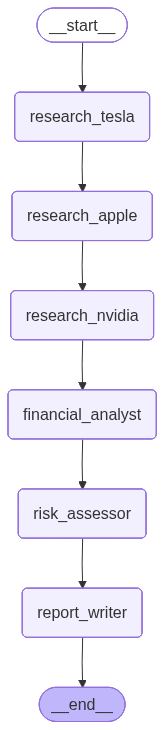

In [59]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))


### 4.4 Run the Multi-Agent System

Now let's execute the full multi-agent pipeline and watch each agent work in sequence.

In [60]:
# ============================================================
# STEP 4.4: Run the Multi-Agent Pipeline
# ============================================================
# We invoke the compiled graph with the initial state.
# LangGraph handles:
#   - Executing each node in order
#   - Passing state between nodes (handoffs)
#   - Collecting all outputs into the final state
# ============================================================

print("="*60)
print("🤖 MULTI-AGENT SYSTEM: Starting pipeline...")
print("="*60)

start_time = time.time()

# Initial state — only the input field is filled
initial_state = {
    "companies": COMPANIES,
    "research_tesla": "",
    "research_apple": "",
    "research_nvidia": "",
    "financial_analysis": "",
    "risk_assessment": "",
    "investment_memo": "",
    "current_agent": "starting"
}

# Run the graph!
final_state = app.invoke(initial_state)

multi_agent_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"✅ MULTI-AGENT PIPELINE COMPLETE!")
print(f"⏱️  Total time: {multi_agent_time:.1f}s")
print(f"{'='*60}")


🤖 MULTI-AGENT SYSTEM: Starting pipeline...

🔍 Research Agent [Tesla]: Starting deep-dive research...
   ✅ Research complete: 17 chars

🔍 Research Agent [Apple]: Starting deep-dive research...
   ✅ Research complete: 8518 chars

🔍 Research Agent [NVIDIA]: Starting deep-dive research...
   ✅ Research complete: 8428 chars

📊 Financial Analyst Agent: Analyzing comparatives...
   ✅ Financial analysis complete: 2955 chars

⚠️ Risk Assessor Agent: Identifying risks...
   ✅ Risk assessment complete: 7594 chars

📝 Report Writer Agent: Synthesizing final memo...
   ✅ Investment memo complete: 4337 chars

✅ MULTI-AGENT PIPELINE COMPLETE!
⏱️  Total time: 297.4s


In [61]:
# ============================================================
# View each agent's individual output
# ============================================================
# One advantage of multi-agent: you can inspect each agent's
# work independently. Try doing that with a single agent!
# ============================================================

print("📋 INDIVIDUAL AGENT OUTPUTS")
print("=" * 60)

sections = [
    ("🔍 Tesla Research", "research_tesla"),
    ("🔍 Apple Research", "research_apple"),
    ("🔍 NVIDIA Research", "research_nvidia"),
    ("📊 Financial Analysis", "financial_analysis"),
    ("⚠️ Risk Assessment", "risk_assessment"),
]

for title, key in sections:
    content = final_state.get(key, "")
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print(f"Length: {len(content)} chars")
    print(content[:1500] + "\n..." if len(content) > 1500 else content)


📋 INDIVIDUAL AGENT OUTPUTS

🔍 Tesla Research
Length: 17 chars
User Safety: safe

🔍 Apple Research
Length: 8518 chars
**Apple Inc. – Equity Research Report (July 2026)**  
*Prepared by: Senior Equity Research Analyst – Consumer Electronics & Services*  

---

## 1. Business Overview  

| Segment | 2025 FY Revenue (USD bn) | YoY % | Notes |
|---------|--------------------------|-------|-------|
| **iPhone** | $179.3 | +5.3% | Hardware revenue rose 5.3 % YoY to $73.7 bn (Apple‑reported) – the largest contributor to total revenue. |
| **Mac** | $28.4 | +3.1% | Continued growth driven by M‑series silicon. |
| **iPad** | $20.1 | +2.8% | Strong demand for education & enterprise bundles. |
| **Wearables, Home & Accessories** | $27.6 | +4.5% | Apple Watch, AirPods, HomePod remain high‑margin. |
| **Services** | $112.0 | +12.4% | Includes App Store, Apple Music, iCloud, Apple Pay, Apple TV+, and new AI‑enabled services. |
| **Other** | $9.8 | +1.2% | Includes Apple Pay, Apple Card, and other anc

In [62]:
# ============================================================
# View the FINAL Investment Memo
# ============================================================

print("📋 FINAL INVESTMENT MEMO (Multi-Agent Output)")
print("=" * 60)
print(final_state.get("investment_memo", "No memo generated"))


📋 FINAL INVESTMENT MEMO (Multi-Agent Output)
# INVESTMENT MEMO: Tech Sector Analysis

**DATE:** June 24, 2026  
**TO:** High-Net-Worth Clients  
**FROM:** AI Investment Research Team  
**SUBJECT:** Strategic Sector Allocation: NVIDIA, Apple, and Tesla

---

### EXECUTIVE SUMMARY
Following a comprehensive review of current market leaders in the technology sector, we recommend a bifurcated approach focusing on high-growth AI infrastructure and stable ecosystem-driven services. NVIDIA remains our primary conviction play due to unprecedented revenue growth and margin expansion driven by data center demand. While Apple offers unparalleled stability through its services segment, we advise caution regarding Tesla due to significant regulatory headwinds and production volatility.

### COMPANY OVERVIEWS
*   **NVIDIA (NVDA):** The undisputed leader in the AI revolution, NVIDIA has transitioned from a gaming-centric hardware provider to a dominant data center powerhouse. Its vertically integrated

---
## 📊 Section 5: Head-to-Head Comparison

Now let's put both approaches side-by-side and see the difference objectively.

In [63]:
# ============================================================
# STEP 5: Evaluate the Multi-Agent output
# ============================================================
# We use the SAME evaluation criteria as before to get an
# apples-to-apples comparison.
# ============================================================

multi_eval_prompt = f"""You are a senior investment analyst reviewing a team's report.
                        Score this report on a scale of 1-10 for each category. Be brutally honest.

                        Categories:
                        1. Research Depth (Are specific numbers, dates, and sources cited?)
                        2. Financial Analysis (Are metrics compared with actual data, not generic statements?)
                        3. Risk Assessment (Are risks specific and non-obvious, not just generic disclaimers?)
                        4. Recommendation Quality (Is the buy/hold/sell backed by the analysis above?)
                        5. Overall Professionalism (Would you send this to a client?)

                        For each category, give:
                        - Score (1-10)
                        - One specific strength you noticed

                        Report to evaluate:
                        {final_state.get('investment_memo', '')[:6000]}
                        """

multi_evaluation = llm.invoke([HumanMessage(content=multi_eval_prompt)])

print("📊 MULTI-AGENT EVALUATION")
print("=" * 60)
print(multi_evaluation.content)


📊 MULTI-AGENT EVALUATION
**1. Research Depth – Score: 4/10**  
- **Strength:** The memo supplies concrete financial figures (e.g., FY 2025 revenue of $130.5 B for NVIDIA, 66.5% gross margin) and cites specific growth rates, giving the analysis a quantitative backbone rather than vague statements.

**2. Financial Analysis – Score: 5/10**  
- **Strength:** It compares actual margin and revenue metrics across the three firms in a side‑by‑side table, allowing a clear view of NVIDIA’s outlier profitability versus Apple’s more modest margins.

**3. Risk Assessment – Score: 3/10**  
- **Strength:** The memo pinpoints concrete regulatory threats (EU Digital Markets Act for Apple, NHTSA investigations and FSD scrutiny for Tesla), which are more specific than generic “market risk” disclaimers.

**4. Recommendation Quality – Score: 6/10**  
- **Strength:** The BUY/HOLD/SELL ratings are directly tied to the underlying financial and risk points (e.g., NVIDIA’s dominant AI infrastructure and superio

In [64]:
# ============================================================
# FINAL COMPARISON: Single Agent vs Multi-Agent
# ============================================================

multi_agent_memo = final_state.get("investment_memo", "")

print("\n" + "="*70)
print("📊 FINAL COMPARISON: SINGLE AGENT vs MULTI-AGENT")
print("="*70)

print(f"\n{'Metric':<35} {'Single Agent':<20} {'Multi-Agent':<20}")
print("-"*75)
print(f"{'Total Time':<35} {single_agent_result['time']:.1f}s{'':<14} {multi_agent_time:.1f}s")
print(f"{'Output Length':<35} {single_agent_result['output_length']:<20} {len(multi_agent_memo):<20}")
print(f"{'Specialized Agents Used':<35} {'1':<20} {'6':<20}")
print(f"{'Independent Research per Company':<35} {'No':<20} {'Yes':<20}")
print(f"{'Dedicated Risk Analysis':<35} {'No':<20} {'Yes':<20}")
print(f"{'Financial Comparison':<35} {'Generic':<20} {'Data-driven':<20}")
print(f"{'Can Inspect Individual Steps':<35} {'No':<20} {'Yes':<20}")
print(f"{'Architecture':<35} {'Monolithic':<20} {'Supervisor':<20}")

print("\n" + "="*70)
print("🏆 VERDICT")
print("="*70)
print("""
The Multi-Agent System produces significantly better results because:

1. DEEPER RESEARCH — Each company gets its own dedicated research agent
   with multiple focused search queries, instead of one vague search.

2. BETTER ANALYSIS — The financial analyst only focuses on comparison,
   working with high-quality research data as input.

3. SPECIFIC RISKS — The risk assessor does its own searches and produces
   company-specific risks, not generic disclaimers.

4. PROFESSIONAL OUTPUT — The report writer synthesizes expert analysis
   into a polished memo, rather than trying to do everything at once.

5. DEBUGGABLE — You can inspect each agent's output independently
   and improve individual agents without affecting others.
""")



📊 FINAL COMPARISON: SINGLE AGENT vs MULTI-AGENT

Metric                              Single Agent         Multi-Agent         
---------------------------------------------------------------------------
Total Time                          114.0s               297.4s
Output Length                       6550                 4337                
Specialized Agents Used             1                    6                   
Independent Research per Company    No                   Yes                 
Dedicated Risk Analysis             No                   Yes                 
Financial Comparison                Generic              Data-driven         
Can Inspect Individual Steps        No                   Yes                 
Architecture                        Monolithic           Supervisor          

🏆 VERDICT

The Multi-Agent System produces significantly better results because:

1. DEEPER RESEARCH — Each company gets its own dedicated research agent
   with multiple focused search

## 🎓 Section 6: Key Takeaways

### What We Built

| Component | What It Does |
|---|---|
| **3 Research Agents** | Deep-dive research on Tesla, Apple, NVIDIA |
| **1 Financial Analyst** | Comparative financial analysis |
| **1 Risk Assessor** | Company-specific risk identification |
| **1 Report Writer** | Professional investment memo synthesis |
| **LangGraph Orchestrator** | Manages the workflow and state |

### Architecture Used: Sequential + Parallel

- **Sequential Pattern** — Research → Analysis → Risk → Report flows in order (each step depends on the previous)
- **Parallel Pattern** — The 3 research agents are independent and can run simultaneously in production

### Communication Approach: Shared State (Final Results Only)

We used the **"Sharing Only Final Results"** approach:
- Each agent writes only its final output to the shared state
- Downstream agents read only what they need
- This keeps context manageable and avoids the "chatty loops" anti-pattern

### Design Checklist Applied

| Checklist Item | How We Applied It |
|---|---|
| ✅ Clear Roles | Each agent has a specific job title and system prompt |
| ✅ Structured Communication | Agents communicate via typed state fields |
| ✅ Shared Memory | `InvestmentState` TypedDict is the shared state |
| ✅ Stop Conditions | Graph has a defined END node — no infinite loops |
| ✅ Incremental Scaling | Started with 3 research agents, can add more |

### When to Use Multi-Agent

✅ **Use multi-agent when:**
- The task requires diverse skills (research + analysis + writing)
- You need parallel execution for latency-sensitive workflows
- Quality matters and self-review is important
- You want to debug and improve individual components

❌ **Don't use multi-agent when:**
- The task is simple and can be done in one prompt
- Cost is a primary concern (~15x more tokens than single agent)
- The subtasks are tightly coupled and can't be separated

---

### 🚀 Next Steps for Production

To make this production-ready, you would add:
1. **Parallel execution** — Run all 3 research agents simultaneously using LangGraph's `Send` API
2. **Error handling** — Retry failed searches, fallback prompts
3. **Human-in-the-loop** — Allow analyst to review before final memo
4. **Checkpointing** — Save intermediate state for long-running workflows
5. **Cost tracking** — Monitor token usage per agent
6. **Guardrails** — Content filters on financial recommendations (compliance)

## Section 7: Run Agents in Parallel

In [66]:
# ============================================================
# This agent specializes in RESEARCHING a single company.
# It uses the Tavily search tool to find real-time data.
#
# Key design choices:
#   - Focused on ONE company at a time (avoids context mixing)
#   - Multiple targeted search queries (not one vague query)
#   - Structured output format for downstream agents
# ============================================================

def create_research_agent(company: str):
    """Creates a research agent function for a specific company."""

    def research_node(state: InvestmentState) -> dict:
        """Research agent node — deep-dives into one company."""

        print(f"\n🔍 Research Agent [{company}]: Starting deep-dive research...")

        # ---------------------------------------------------
        # Multiple targeted searches (not one vague query)
        # This is what makes multi-agent better — focused queries
        # ---------------------------------------------------
        search_queries = [
            f"{company} revenue earnings Q4 2024 2025 financial results",
            f"{company} AI strategy artificial intelligence initiatives 2025",
            f"{company} stock price target analyst ratings 2025",
            f"{company} competitive advantages market position"
        ]

        all_results = ""
        for query in search_queries:
            try:
                results = search_tool.invoke(query)['results']
                for r in results:
                    all_results += f"- {r['content'][:400]}\n"
            except Exception as e:
                print(f"   ⚠️ Search error for query '{query}': {e}")

        # ---------------------------------------------------
        # Use LLM to synthesize research into structured report
        # ---------------------------------------------------
        research_prompt = f"""You are a senior equity research analyst specializing in {company}.

                              Based on the following search results, produce a DETAILED research report on {company}.

                              Your report MUST include (with specific numbers where available):

                              1. **Business Overview**: What the company does, key segments, market position
                              2. **Recent Financial Performance**: Revenue, earnings, growth rates, margins (cite specific numbers)
                              3. **AI Strategy & Initiatives**: How the company is leveraging AI
                              4. **Competitive Position**: Key advantages and threats
                              5. **Analyst Consensus**: Price targets, ratings if available

                              Be SPECIFIC — use actual numbers, dates, and facts. No vague statements.

                              Search Results:
                              {all_results[:6000]}
                              """

        response = llm.invoke([HumanMessage(content=research_prompt)])

        print(f"   ✅ Research complete: {len(response.content)} chars")

        # Write to the correct state field based on company
        # This is the HANDOFF — passing output to shared state
        key = f"research_{company.lower()}"
        return {key: response.content}

    return research_node


# Create research agents for each company
research_tesla = create_research_agent("Tesla")
research_apple = create_research_agent("Apple")
research_nvidia = create_research_agent("NVIDIA")

print("✅ Research Agents created for: Tesla, Apple, NVIDIA")


✅ Research Agents created for: Tesla, Apple, NVIDIA


In [67]:
## let's make this work in parallel
from typing import Annotated
import operator
class InvestmentState(TypedDict):
    """Shared state that flows between all agents in the graph."""

    # Input
    companies: list                    # List of companies to analyze

    # Research outputs (one per company)
    research_tesla: str                # Tesla research findings
    research_apple: str                # Apple research findings
    research_nvidia: str               # NVIDIA research findings

    # Analysis outputs
    financial_analysis: str            # Comparative financial analysis
    risk_assessment: str               # Risk assessment for all companies

    # Final output
    investment_memo: str               # The final investment memo

    # Metadata
    current_agent: str                 # Which agent is currently working

print("✅ State schema defined!")
print("📦 State fields:", list(InvestmentState.__annotations__.keys()))


✅ State schema defined!
📦 State fields: ['companies', 'research_tesla', 'research_apple', 'research_nvidia', 'financial_analysis', 'risk_assessment', 'investment_memo', 'current_agent']


In [68]:
# ============================================================
# STEP 4.3: Build the LangGraph Workflow
# ============================================================
# Graph structure:
#
#              ┌──► research_tesla  ──┐
#              │                      │
#   START ─────┼──► research_apple  ──┼──► financial_analyst → risk_assessor → report_writer → END
#              │                      │
#              └──► research_nvidia ──┘
#
# The 3 research nodes run in PARALLEL (fan-out from START,
# fan-in to financial_analyst). LangGraph waits for all three
# to finish before financial_analyst begins.
# ============================================================

workflow = StateGraph(InvestmentState)

# ---------------------------------------------------
# Add NODES (unchanged)
# ---------------------------------------------------
workflow.add_node("research_tesla",    research_tesla)
workflow.add_node("research_apple",    research_apple)
workflow.add_node("research_nvidia",   research_nvidia)
workflow.add_node("financial_analyst", financial_analyst_node)
workflow.add_node("risk_assessor",     risk_assessor_node)
workflow.add_node("report_writer",     report_writer_node)

# ---------------------------------------------------
# Add EDGES
# ---------------------------------------------------
# Phase 1: Research — fan-out from START to all 3 agents simultaneously
workflow.add_edge(START, "research_tesla")
workflow.add_edge(START, "research_apple")
workflow.add_edge(START, "research_nvidia")

# Fan-in: financial_analyst starts only after ALL THREE research nodes complete
workflow.add_edge("research_tesla",  "financial_analyst")
workflow.add_edge("research_apple",  "financial_analyst")
workflow.add_edge("research_nvidia", "financial_analyst")

# Phase 2 & 3: Sequential — each builds on prior output (unchanged)
workflow.add_edge("financial_analyst", "risk_assessor")
workflow.add_edge("risk_assessor",     "report_writer")
workflow.add_edge("report_writer",     END)

# ---------------------------------------------------
# Compile
# ---------------------------------------------------
app = workflow.compile()

print("✅ LangGraph workflow compiled!")
print("\n📊 Graph nodes:", list(app.get_graph().nodes.keys()))
print("🔗 Phase 1 (parallel): START → [research_tesla, research_apple, research_nvidia]")
print("🔗 Phase 2 (sequential): financial_analyst → risk_assessor → report_writer → END")


✅ LangGraph workflow compiled!

📊 Graph nodes: ['__start__', 'research_tesla', 'research_apple', 'research_nvidia', 'financial_analyst', 'risk_assessor', 'report_writer', '__end__']
🔗 Phase 1 (parallel): START → [research_tesla, research_apple, research_nvidia]
🔗 Phase 2 (sequential): financial_analyst → risk_assessor → report_writer → END


In [69]:
# ============================================================
# Visualize the Graph (optional but helpful for understanding)
# ============================================================

try:
    # LangGraph can render the workflow as a Mermaid diagram
    graph_image = app.get_graph().draw_mermaid()
    print("📊 Graph Visualization (Mermaid format):")
    print(graph_image)
except Exception as e:
    print(f"Graph visualization not available: {e}")
    print("\nManual visualization:")
    print("START → research_tesla → research_apple → research_nvidia")
    print("  → financial_analyst → risk_assessor → report_writer → END")


📊 Graph Visualization (Mermaid format):
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	research_tesla(research_tesla)
	research_apple(research_apple)
	research_nvidia(research_nvidia)
	financial_analyst(financial_analyst)
	risk_assessor(risk_assessor)
	report_writer(report_writer)
	__end__([<p>__end__</p>]):::last
	__start__ --> research_apple;
	__start__ --> research_nvidia;
	__start__ --> research_tesla;
	financial_analyst --> risk_assessor;
	research_apple --> financial_analyst;
	research_nvidia --> financial_analyst;
	research_tesla --> financial_analyst;
	risk_assessor --> report_writer;
	report_writer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



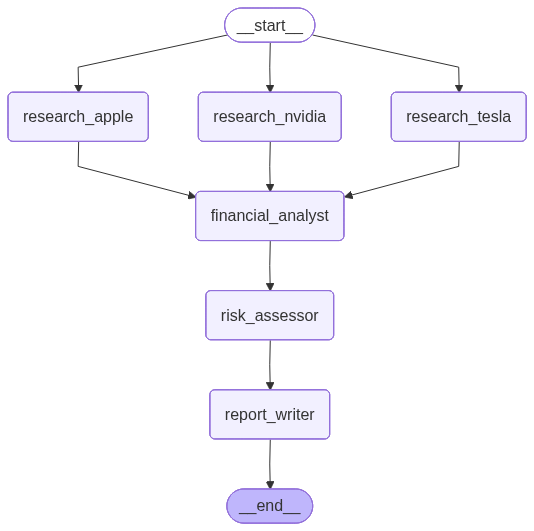

In [70]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))


In [71]:
# ============================================================
# STEP 4.4: Run the Multi-Agent Pipeline
# ============================================================
# We invoke the compiled graph with the initial state.
# LangGraph handles:
#   - Executing each node in order
#   - Passing state between nodes (handoffs)
#   - Collecting all outputs into the final state
# ============================================================

print("="*60)
print("🤖 MULTI-AGENT SYSTEM: Starting pipeline...")
print("="*60)

start_time = time.time()

# Initial state — only the input field is filled
initial_state = {
    "companies": COMPANIES,
    "research_tesla": "",
    "research_apple": "",
    "research_nvidia": "",
    "financial_analysis": "",
    "risk_assessment": "",
    "investment_memo": "",
    "current_agent": "starting"
}

# Run the graph!
final_state = app.invoke(initial_state)

multi_agent_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"✅ MULTI-AGENT PIPELINE COMPLETE!")
print(f"⏱️  Total time: {multi_agent_time:.1f}s")
print(f"{'='*60}")


🤖 MULTI-AGENT SYSTEM: Starting pipeline...

🔍 Research Agent [Apple]: Starting deep-dive research...

🔍 Research Agent [NVIDIA]: Starting deep-dive research...

🔍 Research Agent [Tesla]: Starting deep-dive research...
   ✅ Research complete: 10748 chars
   ✅ Research complete: 8719 chars
   ✅ Research complete: 9438 chars

📊 Financial Analyst Agent: Analyzing comparatives...
   ✅ Financial analysis complete: 2826 chars

⚠️ Risk Assessor Agent: Identifying risks...
   ✅ Risk assessment complete: 15679 chars

📝 Report Writer Agent: Synthesizing final memo...
   ✅ Investment memo complete: 4885 chars

✅ MULTI-AGENT PIPELINE COMPLETE!
⏱️  Total time: 98.8s


In [72]:
# ============================================================
# View each agent's individual output
# ============================================================
# One advantage of multi-agent: you can inspect each agent's
# work independently. Try doing that with a single agent!
# ============================================================

print("📋 INDIVIDUAL AGENT OUTPUTS")
print("=" * 60)

sections = [
    ("🔍 Tesla Research", "research_tesla"),
    ("🔍 Apple Research", "research_apple"),
    ("🔍 NVIDIA Research", "research_nvidia"),
    ("📊 Financial Analysis", "financial_analysis"),
    ("⚠️ Risk Assessment", "risk_assessment"),
]

for title, key in sections:
    content = final_state.get(key, "")
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print(f"Length: {len(content)} chars")
    print(content[:1500] + "\n..." if len(content) > 1500 else content)


📋 INDIVIDUAL AGENT OUTPUTS

🔍 Tesla Research
Length: 10748 chars
**Tesla, Inc. (TSLA) – Senior Equity Research Report**  
*Prepared: 3 Nov 2025*  

---

### 1. Business Overview  
- **Core Operations** – Tesla designs, manufactures, and sells electric vehicles (EVs), energy generation and storage products, and related services. The company also develops artificial‑intelligence (AI)‑driven software for autonomous driving and robotics.  
- **Key Segments** (as implied by the sources):  
  1. **Automotive** – Vehicle sales (Model S, 3, X, Y, Cybertruck, future models).  
  2. **Energy Generation & Storage** – Solar‑roof, Powerwall, Powerpack, Megapack.  
  3. **AI & Robotics** – Full‑Self‑Driving (FSD) neural‑net software, Optimus humanoid robot, AI‑based manufacturing and logistics systems.  
- **Market Position** – Tesla is described as a “revolutionary force” that is changing perception and interaction with electric automobiles, leveraging a differentiation strategy that emphasizes inn

In [ ]:
# ============================================================
# View the FINAL Investment Memo
# ============================================================

print("📋 FINAL INVESTMENT MEMO (Multi-Agent Output)")
print("=" * 60)
print(final_state.get("investment_memo", "No memo generated"))
